# Soil X-ray CT Segmentation — Prototype Development

This notebook documents the steps used to prepare a soil CT image for annotation and later nnU-Net training.

Current workflow:

1. Load the 3D TIFF stack.
2. Inspect the image and intensity distribution.
3. Normalize the image.
4. Select the middle slice.
5. Use Otsu thresholding to create an initial soil matrix mask.
6. Open the image and labels in Napari for manual annotation.
7. Save the annotation for later nnU-Net processing.

## 1. Load the 3D Soil X-ray CT Stack
Load the TIFF stack and check its shape, data type, and intensity range before preprocessing.

In [2]:
import numpy as np

In [3]:
# Find the TIFF
from pathlib import Path

from soilct_segmentation.image_io import load_tiff

input_dir = Path("soilct_segmentation") / "Input data"

tif_files = list(input_dir.glob("*.tif")) + list(input_dir.glob("*.tiff"))

if not tif_files:
    raise FileNotFoundError(
        f"No TIFF files found in {input_dir}"
    )

print(f"Found {len(tif_files)} TIFF file(s):")
for file in tif_files:
    print(f"  {file.name}")

Found 1 TIFF file(s):
  LuxArbor_R1_NS_Norm_16Slices.tif


In [4]:
# Load the TIFF
input_file = tif_files[0]
image = load_tiff(input_file)


Soil CT Image Information
File: LuxArbor_R1_NS_Norm_16Slices.tif
Shape (Z, Y, X): (16, 2385, 2311)
Data type: uint8
Intensity range: 0 to 232


## 2. Image Inspection

Display the middle slice and check the intensity histogram. Zero-valued background voxels are excluded from the histogram.

Number of slices: 16
Middle slice index: 7


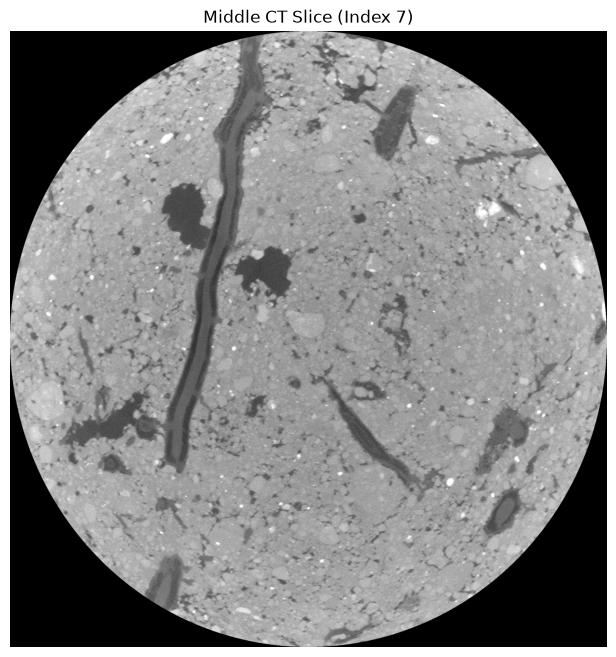

In [5]:
# Middle slice
import matplotlib.pyplot as plt

middle_slice = image.shape[0] // 2 - 1

print(f"Number of slices: {image.shape[0]}")
print(f"Middle slice index: {middle_slice}")

plt.figure(figsize=(8, 8))
plt.imshow(image[middle_slice], cmap="gray")
plt.title(f"Middle CT Slice (Index {middle_slice})")
plt.axis("off")
plt.show()

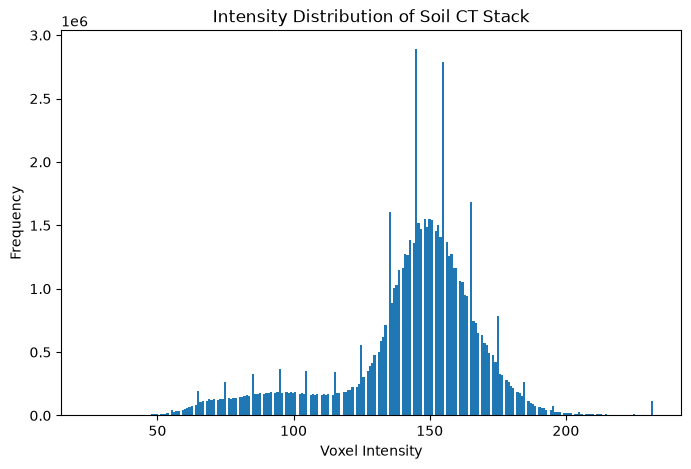

In [6]:
# Histogram
nonzero = image[image > 0]

plt.figure(figsize=(8, 5))
plt.hist(nonzero.ravel(), bins=256)
plt.xlabel("Voxel Intensity")
plt.ylabel("Frequency")
plt.title("Intensity Distribution of Soil CT Stack")
plt.show()

## 3. Normalize the Image

Normalize the CT image before creating the initial annotation. Zero-valued background voxels are kept as zero.

In [7]:
# Normalization
from soilct_segmentation.preprocessing import normalize_image

prepared_image = normalize_image(image)

Image stack normalized to 0-255.


## 4. Initialization of Semi-Automatic Annotation

The annotation approach used here is adapted from the
[nnUNet4SoilXrayCT](https://github.com/MaxPhal/nnUNet4SoilXrayCT)
workflow developed by Phalempin and collaborators.

Otsu thresholding is applied to the non-background voxels of the middle slice to create an initial soil matrix mask. This mask is used only as a starting point and can be corrected or extended with additional classes during manual annotation in Napari.

In [8]:
from skimage.filters import threshold_otsu

middle_image = prepared_image[middle_slice]

# Calculate Otsu threshold using only non-background voxels
# from the slice being annotated
soil_pixels = middle_image[middle_image > 0]

if soil_pixels.size == 0:
    raise ValueError("The selected slice contains no nonzero voxels.")

otsu_threshold = threshold_otsu(soil_pixels)

print(f"Middle slice index: {middle_slice}")
print(f"Otsu threshold: {otsu_threshold}")

Middle slice index: 7
Otsu threshold: 120


### Visual Inspection of the Otsu Initialization

The automatically calculated Otsu threshold is applied to the selected middle
slice to obtain an initial estimate of the soil matrix.

The proposed mask is displayed beside the original CT slice so that its
quality can be evaluated before it is used for annotation.

Because different soil constituents can have overlapping X-ray attenuation
values, the Otsu result is treated only as an initialization rather than a
final segmentation.

In [9]:
# Define the otsu mask
otsu_mask = middle_image > otsu_threshold

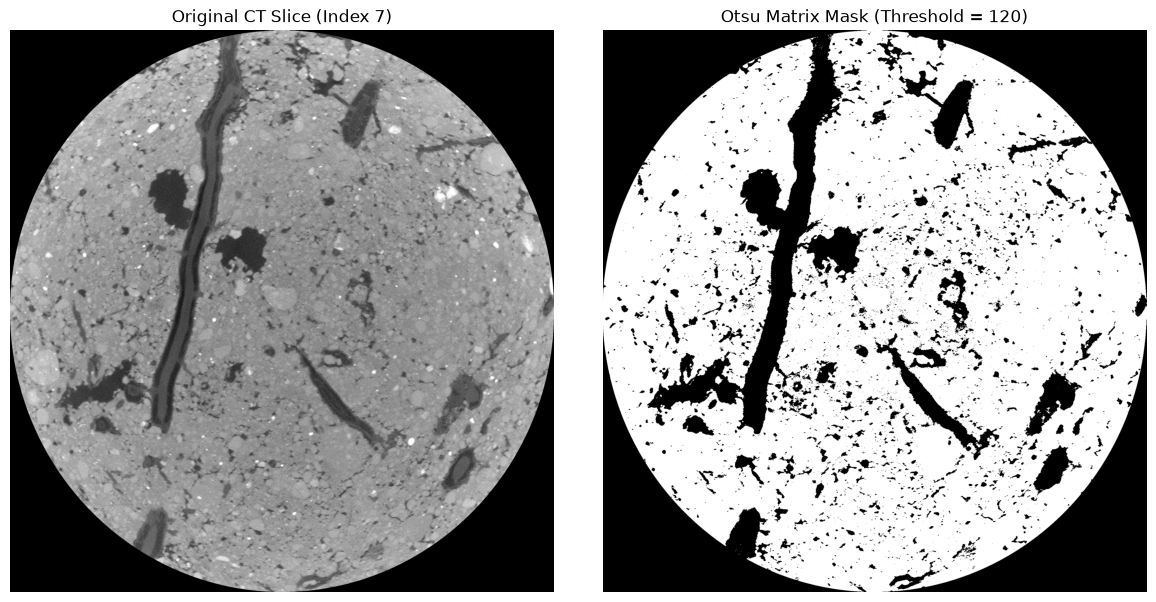

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original CT slice
axes[0].imshow(middle_image, cmap="gray")
axes[0].set_title(f"Original CT Slice (Index {middle_slice})")
axes[0].axis("off")

# Otsu mask
axes[1].imshow(otsu_mask, cmap="gray")
axes[1].set_title(f"Otsu Matrix Mask (Threshold = {otsu_threshold})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Threshold Selection

Otsu is used as the starting lower threshold. The sliders below can be used to adjust the lower and upper thresholds while checking the matrix mask.

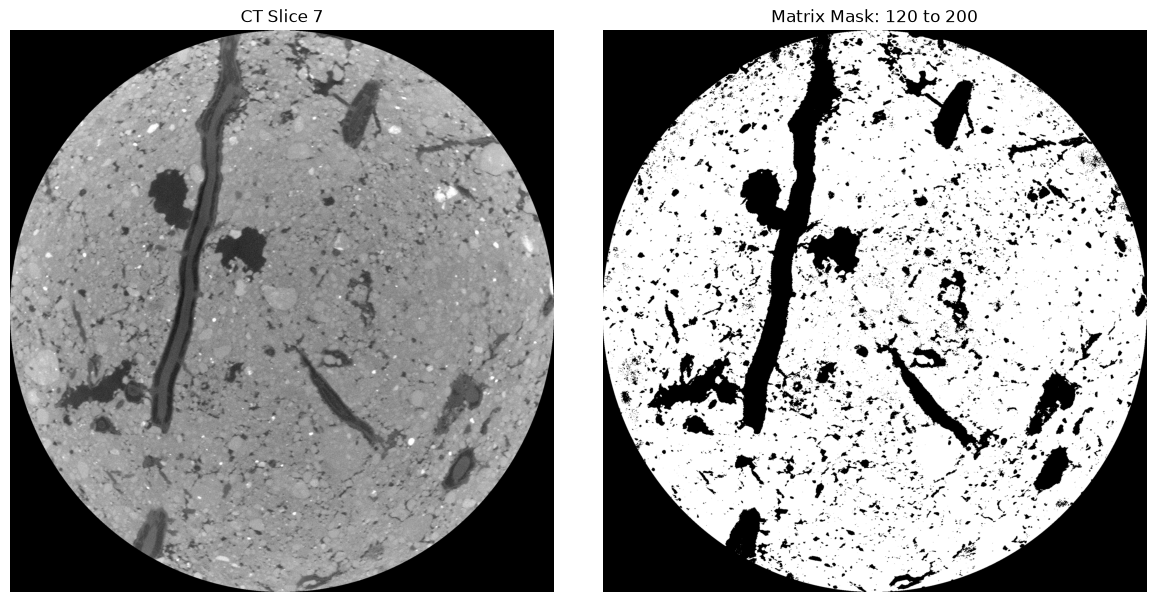

Accept thresholds? Lower=120, Upper=200 (y/n):  Y


Selected thresholds: 120 to 200


In [12]:

lower_threshold = float(otsu_threshold)
upper_threshold = 200.0  # change if the upper threshold is excluding some matrix

while True:
    initial_matrix_mask = (
        (middle_image > lower_threshold) &
        (middle_image < upper_threshold)
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(middle_image, cmap="gray")
    axes[0].set_title(f"CT Slice {middle_slice}")
    axes[0].axis("off")

    axes[1].imshow(initial_matrix_mask, cmap="gray")
    axes[1].set_title(f"Matrix Mask: {lower_threshold:g} to {upper_threshold:g}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    choice = input(
    f"Accept thresholds? Lower={lower_threshold:g}, "
    f"Upper={upper_threshold:g} (y/n): "
).lower()

    if choice == "y":
        break

    lower_threshold = float(input("Lower threshold: "))
    upper_threshold = float(input("Upper threshold: "))

print(f"Selected thresholds: {lower_threshold:g} to {upper_threshold:g}")

In [14]:
#Summary of the loaded 3d tiff stack
soil_area = middle_image > 0
print(f"Matrix voxels: {initial_matrix_mask.sum():,}")
print(f"Matrix coverage: {100 * initial_matrix_mask.sum() / soil_area.sum():.2f}%")

Matrix voxels: 3,562,385
Matrix coverage: 82.29%


## 5. Prepare the 3D Annotation Volume

Load the class labels and colors from `dataset_info.json`. If an annotation already exists, load it; otherwise create a new label volume and initialize the middle slice with the matrix mask.

In [15]:
# The dataset.json file has the defined classes of segmentation and color codes
import json

with open("dataset_info.json") as file:
    dataset_info = json.load(file)

labels_by_id = dataset_info["labels"]
colors_by_id = dataset_info["colors"]
labels_by_name = {name: int(label_id) for label_id, name in labels_by_id.items()}

for label_id, class_name in labels_by_id.items():
    print(f"{label_id}: {class_name}")

0: ToPredict
1: Matrix
2: Stones
3: OrganicMatter
4: Roots
5: Biopores
6: OtherPores


In [16]:
# Load the tiff file of 3d image stack
import tifffile

TO_PREDICT = labels_by_name["ToPredict"]
MATRIX = labels_by_name["Matrix"]

annotation_dir = Path("soilct_segmentation") / "Annotations"
annotation_dir.mkdir(parents=True, exist_ok=True)
annotation_file = annotation_dir / f"{input_file.stem}_labels.tif"

if annotation_file.exists():
    labels_3d = tifffile.imread(annotation_file)

    if labels_3d.shape != prepared_image.shape:
        raise ValueError("Saved annotation shape does not match the image shape.")

    print(f"Loaded existing annotation: {annotation_file}")

else:
    labels_3d = np.full(prepared_image.shape, TO_PREDICT, dtype=np.uint8)
    labels_3d[middle_slice][initial_matrix_mask] = MATRIX

    print(f"Created new annotation: {annotation_file}")

print(f"Annotation shape: {labels_3d.shape}")

Loaded existing annotation: soilct_segmentation\Annotations\LuxArbor_R1_NS_Norm_16Slices_labels.tif
Annotation shape: (16, 2385, 2311)


In [17]:
#Only to check the number of voxels that need to be labeled
unique_labels, counts = np.unique(labels_3d, return_counts=True)

print("\nLabels currently present:")

for label_id, count in zip(unique_labels, counts, strict=True):
    class_name = labels_by_id[str(label_id)]
    print(f"  {label_id}: {class_name} -> {count:,} voxels")


Labels currently present:
  0: ToPredict -> 84,455,025 voxels
  1: Matrix -> 3,600,255 voxels
  2: Stones -> 9,914 voxels
  4: Roots -> 60,694 voxels
  5: Biopores -> 61,872 voxels


## 6. Open the Image and Labels in Napari

Open the CT image and annotation volume in Napari for manual editing.

In [20]:
%gui qt

import napari

viewer = napari.Viewer()

In [21]:
napari_colors = {
    int(label_id): [rgb[0]/255, rgb[1]/255, rgb[2]/255, 1]
    for label_id, rgb in colors_by_id.items()
}

viewer.add_image(prepared_image, name="Soil CT", colormap="gray")

label_layer = viewer.add_labels(
    labels_3d,
    name="Annotations",
    colormap=napari_colors,
    opacity=0.7,
    blending="additive"
)

C:\Users\thotaku4\conda-envs\soilct\Lib\site-packages\napari\utils\colormaps\colormap.py:477: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


In [44]:
# Define a function that saves the current Napari annotation layer

def save_annotations():
    """Save the current Napari annotation layer as a 3D TIFF stack."""
    annotation_data = np.asarray(label_layer.data, dtype=np.uint8)
    tifffile.imwrite(annotation_file, annotation_data)
    print(f"Annotations saved to: {annotation_file}")

In [45]:
#  Allow Ctrl+S in Napari to manually save the current annotations

@viewer.bind_key("Control-S", overwrite=True)
def manual_save(viewer): save_annotations()

In [46]:
# Auto saving the annotations when napari window is closed
qt_window = viewer.window._qt_window
original_close_event = qt_window.closeEvent

def close_event_with_save(event):
    save_annotations()
    original_close_event(event)

qt_window.closeEvent = close_event_with_save

Annotations saved to: soilct_segmentation\Annotations\LuxArbor_R1_NS_Norm_16Slices_labels.tif
